In [1]:
from importlib import reload
from tqdm import tqdm
import numpy as np 
import matplotlib.pyplot as plt
import meanfield.hebbian_meanfield as mf
from glob import glob
import pandas as pd
reload(mf) 
const = 2 * np.pi

In [6]:
def get_all_freq_ims(p):
    ar = np.load(p,allow_pickle=True).item() 
    Xh = ar['Xh']
    nbatch = Xh.shape[0]
    freqs, trajs = [], [] 
    for b in range(5): 
        fr, tvec = mf.get_inst_freq(Xh[b],ar['T'],ar['halt_time'],ar['dt'])
        eigt = ar['eigs'][-len(fr):, b]
        out_index = np.abs(eigt).argmax(axis=-1)
        out_traj = eigt[np.arange(eigt.shape[0]), out_index]
        freqs.append(fr) ; trajs.append(np.abs(out_traj.imag))
    return np.stack(freqs), np.stack(trajs), tvec 

def process_im_results(paths): 
    all_f, all_t = [], []
    for p in tqdm(paths): 
        f, t, tvec = get_all_freq_ims(p)
        all_f.append(f), all_t.append(t)
    return np.stack(all_f), np.stack(all_t),tvec
    
def plot_trc(x, T, dt, halt_time,ax,c='k'):
    t = np.linspace(0,T,int(T/dt))
    for i in range(5):
        ax.plot(t-halt_time*T,x[:,i],color=c, alpha=0.2*(i+1))
    ylim = ax.get_ylim() 
    ax.vlines(0, ylim[0],ylim[1], ls='--', color='grey')
    ax.set_ylim(ylim)
    ax.set_xlim(-T*halt_time, T*(1-halt_time))
    ax.set_xlabel("t", fontsize=fn) 
    ax.set_ylabel("x(t)", fontsize=fn) 


def plot_freq_im(ar, ax): 
    fr,tvec = mf.get_inst_freq(ar['Xh'][b],ar['T'],ar['halt_time'],ar['dt'],
                              use_full=True)
    eigt = ar['eigs'][-len(fr):, b]
    out_index = np.abs(eigt).argmax(axis=-1)
    out_traj = eigt[np.arange(eigt.shape[0]), out_index]
    
    ax.plot(tvec, out_traj.imag/const, lw=2, color='k')
    ax.set_ylabel(r"Im($\lambda$)/2$\pi$", fontsize=fn) 
    
    
    ax2 = ax.twinx() 
    c2='purple'
    ax2.plot(tvec, fr,  lw=2, color=c2, label='freq.')
    ax2.set_ylabel("instantaneous freq.", color=c2, fontsize=fn)
    ax2.tick_params(axis='y', labelcolor=c2)
    ax.legend(fontsize=fn) 
    ax.set_xlabel("t", fontsize=fn) 
    ax.set_xlim(-ar['T'] * ar['halt_time'], ar['T']-ar['T'] * ar['halt_time'])

    ylim=ax.get_ylim() 
    ax.vlines(0, ylim[0],ylim[1], ls='--', color='grey')
    ax.set_ylim(ylim)
    
    
    

In [3]:
from scipy.interpolate import make_smoothing_spline

In [4]:
paths = glob('/mnt/home/awakhloo/ceph/persistent-oscillations/results/eig_at_halt/A-matrices-dt-0.1_grid_imlambdafreq_N_500/*.npy')
F, T, tvec = process_im_results(paths) 
dat = pd.DataFrame({'fr' : F.reshape(-1), 
                    'tr' : T.reshape(-1)})
mdat = dat.groupby('fr').median().reset_index() 
sdat = dat.groupby('fr').sem().reset_index() 

example ='/mnt/home/awakhloo/ceph/persistent-oscillations/results/eig_at_halt/A-matrices-dt-0.1_grid_imlambdafreq_N_500/eigvals_p_20_I_0.75_f_0.1_g_1.3_k_3.0.npy' 
ar = np.load(example,allow_pickle=True).item()

100%|██████████| 8/8 [00:42<00:00,  5.29s/it]


/tmp/ipykernel_3533768/400620189.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=fn)


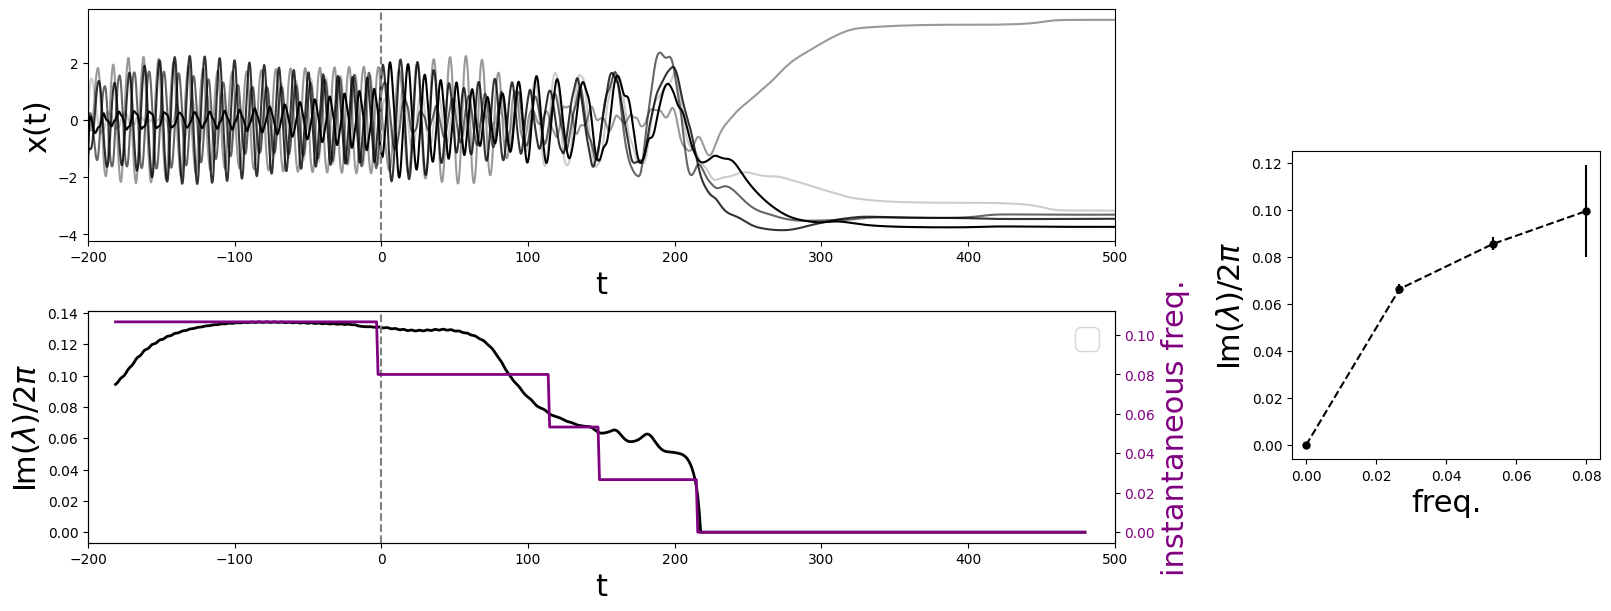

In [7]:
fig = plt.figure(layout='constrained', figsize=(16,6))
fn=22

b = 3

# fa, fb,fc = fig.subfigures(ncols=3, width_ratios=[2,2,1]) 
fa,fc = fig.subfigures(ncols=2, width_ratios=[3,1]) 


axa,axb = fa.subplots(2)

plot_trc(ar['Xh'][b], ar['T'], ar['dt'], ar['halt_time'], ax=axa)
plot_freq_im(ar, axb)

axc = fc.subplots()
axc.errorbar(mdat.fr, mdat.tr/const, yerr=sdat.tr, ls='--', marker='.', ms=10, color='k' )
axc.set_xlabel("freq.", fontsize=fn) 
axc.set_ylabel(r"Im($\lambda$)/2$\pi$", fontsize=fn) 
axc.set_box_aspect(1)

fig.savefig('/mnt/home/awakhloo/ceph/persistent-oscillations/figs/sm_figs/im.png',
            dpi=300, bbox_inches='tight') 